# Part 1: Capital Bikeshare Demand Analysis & Forecasting
**PhD Technical Assessment — UNLV Dept. of Civil & Environmental Engineering and Construction, Dr. Sohn's Research Lab**

Prepared by: Nuzhat Raisa



In [49]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import variance_inflation_factor
import lightgbm as lgb
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams.update({'figure.dpi': 110, 'font.size': 10,
                      'axes.spines.top': False, 'axes.spines.right': False})
pd.set_option('display.width', 120)

import os

def _select_hour_csv():
    """Locate hour.csv, falling back to an interactive 'choose file from your
    computer' dialog if it isn't found automatically."""
    candidates = ['data/hour.csv', 'hour.csv', './data/hour.csv', '../data/hour.csv', '../hour.csv']
    for p in candidates:
        if os.path.exists(p):
            print(f"Found hour.csv at: {p}")
            return p

    # If the file is not found, upload it manually.
    try:
        import google.colab  # noqa: F401
        from google.colab import files
        print("Select hour.csv from your computer (a browser upload dialog will open):")
        uploaded = files.upload()
        chosen = next(iter(uploaded.keys()))
        print(f"Using uploaded file: {chosen}")
        return chosen
    except ImportError:
        pass  # not running in Colab

    try:
        import tkinter as tk
        from tkinter import filedialog
        root = tk.Tk()
        root.withdraw()
        root.attributes('-topmost', True)
        chosen = filedialog.askopenfilename(
            title="Select hour.csv (UCI Bike Sharing Dataset)",
            filetypes=[("CSV files", "*.csv"), ("All files", "*.*")],
        )
        root.destroy()
        if chosen:
            print(f"Selected: {chosen}")
            return chosen
    except Exception:
        pass  # no display / tkinter unavailable (e.g. a headless server)

    manual = input("Could not open a file dialog. Enter the full path to hour.csv: ").strip()
    if not manual or not os.path.exists(manual):
        raise FileNotFoundError("hour.csv was not found. Please provide a valid path and re-run this cell.")
    return manual

hour = pd.read_csv(_select_hour_csv(), parse_dates=['dteday'])
hour['datetime'] = hour['dteday'] + pd.to_timedelta(hour['hr'], unit='h')
hour = hour.sort_values('datetime').reset_index(drop=True)

season_map  = {1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'}
weather_map = {1:'Clear', 2:'Mist/Cloudy', 3:'Light Snow/Rain', 4:'Heavy Rain/Snow'}
hour['season_name']  = hour['season'].map(season_map)
hour['weather_name'] = hour['weathersit'].map(weather_map)
hour['daytype'] = np.where(hour['workingday']==1, 'Working day', 'Weekend/Holiday')

print(f"Shape: {hour.shape}")
hour.head()

Found hour.csv at: hour.csv
Shape: (17379, 21)


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,...,atemp,hum,windspeed,casual,registered,cnt,datetime,season_name,weather_name,daytype
0,1,2011-01-01,1,0,1,0,0,6,0,1,...,0.2879,0.81,0.0,3,13,16,2011-01-01 00:00:00,Spring,Clear,Weekend/Holiday
1,2,2011-01-01,1,0,1,1,0,6,0,1,...,0.2727,0.80,0.0,8,32,40,2011-01-01 01:00:00,Spring,Clear,Weekend/Holiday
2,3,2011-01-01,1,0,1,2,0,6,0,1,...,0.2727,0.80,0.0,5,27,32,2011-01-01 02:00:00,Spring,Clear,Weekend/Holiday
3,4,2011-01-01,1,0,1,3,0,6,0,1,...,0.2879,0.75,0.0,3,10,13,2011-01-01 03:00:00,Spring,Clear,Weekend/Holiday
4,5,2011-01-01,1,0,1,4,0,6,0,1,...,0.2879,0.75,0.0,0,1,1,2011-01-01 04:00:00,Spring,Clear,Weekend/Holiday


## Task 1 — Descriptive Statistics & Exploratory Analysis

First, I explored the data to understand the rental patterns before building any models. I checked the time coverage, rental distribution, rider types, weather, season, and unusual observations. These findings helped me decide which variables and models to use later.


### 1.1 Data quality and time coverage
  
I first checked missing values and hourly timestamps to make sure missing hours were not treated as zero rentals. This is also important when creating time-based features later.


In [50]:
print("Missing values:", hour.isna().sum().sum())
print("Date range:", hour['datetime'].min(), "to", hour['datetime'].max())

full_range = pd.date_range(hour['datetime'].min(), hour['datetime'].max(), freq='h')
missing_hours = full_range.difference(hour['datetime'])
print(f"Expected hourly records: {len(full_range)}  |  Actual: {len(hour)}  |  Gaps: {len(missing_hours)} hours ({len(missing_hours)/len(full_range):.2%})")
hour[['temp','atemp','hum','windspeed','casual','registered','cnt']].describe().round(2)

Missing values: 0
Date range: 2011-01-01 00:00:00 to 2012-12-31 23:00:00
Expected hourly records: 17544  |  Actual: 17379  |  Gaps: 165 hours (0.94%)


,temp,atemp,hum,windspeed,casual,registered,cnt
count,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00,17379.00
mean,0.50,0.48,0.63,0.19,35.68,153.79,189.46
std,0.19,0.17,0.19,0.12,49.31,151.36,181.39
min,0.02,0.00,0.00,0.00,0.00,0.00,1.00
25%,0.34,0.33,0.48,0.10,4.00,34.00,40.00
50%,0.50,0.48,0.63,0.19,17.00,115.00,142.00
75%,0.66,0.62,0.78,0.25,48.00,220.00,281.00
max,1.00,1.00,1.00,0.85,367.00,886.00,977.00


**Observation:**  
The hourly log contains 17,379 of 17,544 possible hourly timestamps, leaving 165 hours
(~0.9%) absent from the record. These are missing timestamps rather than recorded
zero-demand hours. Because the dataset does not document the cause of these gaps,
they are treated as missing observations rather than true zero rentals.

This distinction becomes especially important in Task 3: lag and rolling features
must represent true elapsed time rather than simply the previous row in the table.


### 1.2 Descriptive statistics

This gives a quick overview of the rental and weather variables, including their average values, ranges, and variation. It also helps identify unusual patterns before modeling.


In [51]:
desc_cols = [
    'cnt', 'casual', 'registered',
    'temp', 'atemp', 'hum', 'windspeed'
]

desc_stats = hour[desc_cols].describe().T
desc_stats['median'] = hour[desc_cols].median()
desc_stats['variance'] = hour[desc_cols].var()
desc_stats['skewness'] = hour[desc_cols].skew()

desc_stats = desc_stats[
    ['count', 'mean', 'median', 'std',
     'min', '25%', '50%', '75%', 'max',
     'variance', 'skewness']
]

display(desc_stats.round(3))


,count,mean,median,std,min,25%,50%,75%,max,variance,skewness
cnt,17379.0,189.463,142.000,181.388,1.00,40.000,142.000,281.000,977.000,32901.461,1.277
casual,17379.0,35.676,17.000,49.305,0.00,4.000,17.000,48.000,367.000,2430.986,2.499
registered,17379.0,153.787,115.000,151.357,0.00,34.000,115.000,220.000,886.000,22909.028,1.558
temp,17379.0,0.497,0.500,0.193,0.02,0.340,0.500,0.660,1.000,0.037,-0.006
atemp,17379.0,0.476,0.485,0.172,0.00,0.333,0.485,0.621,1.000,0.030,-0.090
hum,17379.0,0.627,0.630,0.193,0.00,0.480,0.630,0.780,1.000,0.037,-0.111
windspeed,17379.0,0.190,0.194,0.122,0.00,0.104,0.194,0.254,0.851,0.015,0.575


**Observation:**  
The rental-count variables show substantial variability and positive skew, indicating
that low-to-moderate demand hours are common while very high-demand hours occur less
frequently. For `cnt`, the variance is far larger than the mean, suggesting strong
overdispersion. This observation later motivates evaluating count-data models rather
than relying only on ordinary least squares.

The environmental variables are normalized in the source dataset, so their values are
most useful here for comparing relative conditions and relationships.


### 1.3 Target check

Total rentals (`cnt`) should equal casual plus registered rentals. I checked this relationship because casual and registered counts cannot be used to predict `cnt`; they would directly reveal the target.


In [52]:
count_check = hour['cnt'] == (hour['casual'] + hour['registered'])

print(
    "Rows satisfying cnt = casual + registered:",
    f"{count_check.mean() * 100:.2f}%"
)

assert count_check.all()
print("Verified: cnt = casual + registered for every observation.")


Rows satisfying cnt = casual + registered: 100.00%
Verified: cnt = casual + registered for every observation.


**Observation:**  
`cnt = casual + registered` holds for every observation. Therefore, casual and
registered counts are retained for behavioral EDA, where separating user types is
scientifically informative, but they are excluded as predictors of total demand in
the regression and forecasting models to avoid target leakage.


### 1.4 Distribution of hourly rentals

I looked at the distribution of `cnt` to see how hourly demand is spread and whether very high rental counts are common. This helps choose a suitable regression model.


Variance/mean ratio (overdispersion index): 173.7


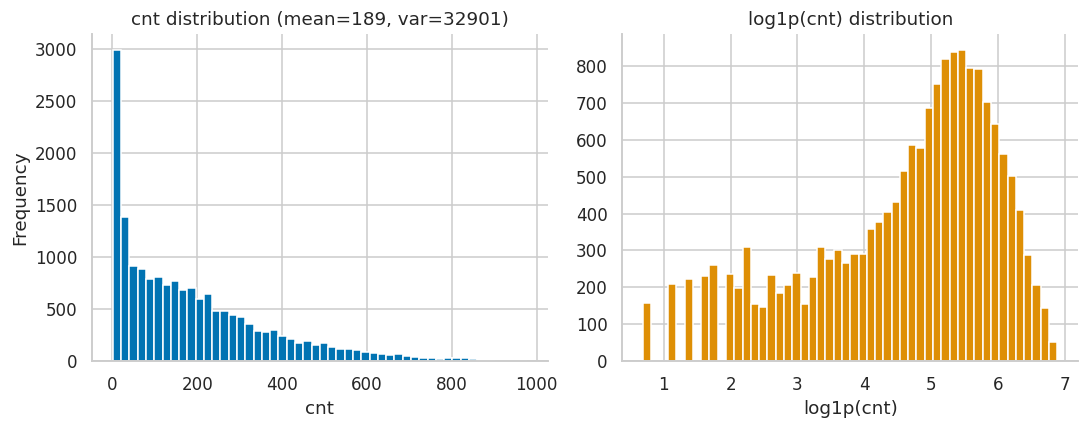

In [53]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].hist(hour['cnt'], bins=50, color=sns.color_palette("colorblind")[0])
axes[0].set_title(f"cnt distribution (mean={hour['cnt'].mean():.0f}, var={hour['cnt'].var():.0f})")
axes[0].set_xlabel('cnt'); axes[0].set_ylabel('Frequency')
axes[1].hist(np.log1p(hour['cnt']), bins=50, color=sns.color_palette("colorblind")[1])
axes[1].set_title('log1p(cnt) distribution'); axes[1].set_xlabel('log1p(cnt)')
fig.tight_layout()
print("Variance/mean ratio (overdispersion index):", round(hour['cnt'].var()/hour['cnt'].mean(), 1))

**Observation:** `cnt` is a non-negative, right-skewed count variable. Its variance (~32,900) is roughly **174×** its mean (~189), i.e. strong **overdispersion** — a critical input to the modeling choices in Task 2. `log1p(cnt)` is far closer to symmetric, motivating a log-link / log-target treatment throughout.

### 1.5 Hourly pattern: working days vs. weekends/holidays

This comparison shows when people use the bikes during a normal day and whether the pattern changes between working days and weekends or holidays.


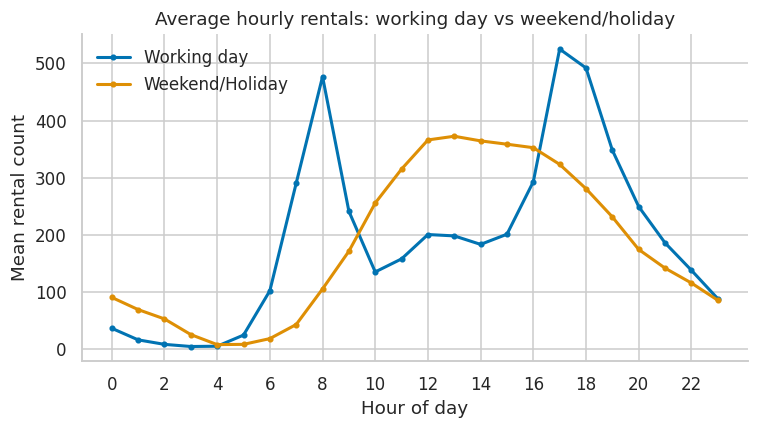

In [54]:
fig, ax = plt.subplots(figsize=(7, 4))
for dt, c in zip(['Working day', 'Weekend/Holiday'], sns.color_palette("colorblind", 2)):
    g = hour[hour['daytype'] == dt].groupby('hr')['cnt'].mean()
    ax.plot(g.index, g.values, marker='o', ms=3, lw=2, label=dt, color=c)
ax.set_xlabel('Hour of day'); ax.set_ylabel('Mean rental count')
ax.set_title('Average hourly rentals: working day vs weekend/holiday')
ax.set_xticks(range(0, 24, 2)); ax.legend(frameon=False)
fig.tight_layout()

**Observation:** working days show a sharp **bimodal commuter pattern** (peaks at 08:00 and 17:00-18:00), while weekends/holidays show a broad **single midday peak** (12:00-16:00) consistent with leisure use.

### 1.6 Casual vs. registered riders

Casual and registered riders may use the system for different reasons. I compared them to see which group creates the commuting peaks and which group is more active during leisure hours.


,casual,registered
workingday,,
0,57.4,124.0
1,25.6,167.6


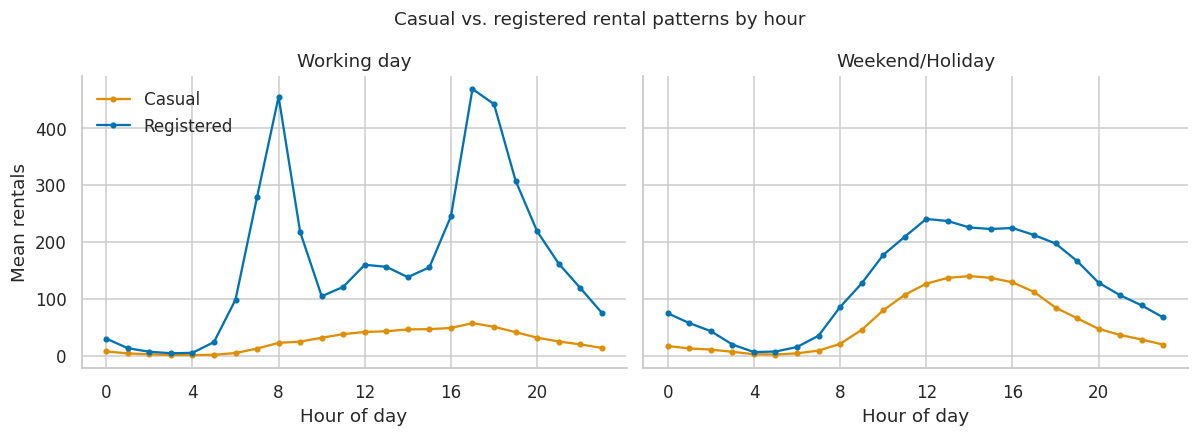

In [55]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4), sharey=True)
for ax, dt in zip(axes, ['Working day', 'Weekend/Holiday']):
    sub = hour[hour['daytype'] == dt].groupby('hr')[['casual', 'registered']].mean()
    ax.plot(sub.index, sub['casual'], marker='o', ms=3, label='Casual', color=sns.color_palette("colorblind")[1])
    ax.plot(sub.index, sub['registered'], marker='o', ms=3, label='Registered', color=sns.color_palette("colorblind")[0])
    ax.set_title(dt); ax.set_xlabel('Hour of day'); ax.set_xticks(range(0, 24, 4))
axes[0].set_ylabel('Mean rentals'); axes[0].legend(frameon=False)
fig.suptitle('Casual vs. registered rental patterns by hour')
fig.tight_layout()

display(hour.groupby('workingday')[['casual','registered']].mean().round(1))

**Observation:** the commuter double-peak is driven almost entirely by **registered** riders; casual riders show a smooth midday-weighted profile on both day types and are markedly more weekend-skewed (mean 57.4 casual rentals/hr on weekends vs. 25.6 on working days, the reverse of registered riders: 124.0 vs. 167.6). This is the clearest behavioral split in the dataset and is revisited quantitatively in Task 2.

### 1.7 Season and weather

Bike use can change with season and weather. This comparison helps show how demand changes under different environmental conditions.


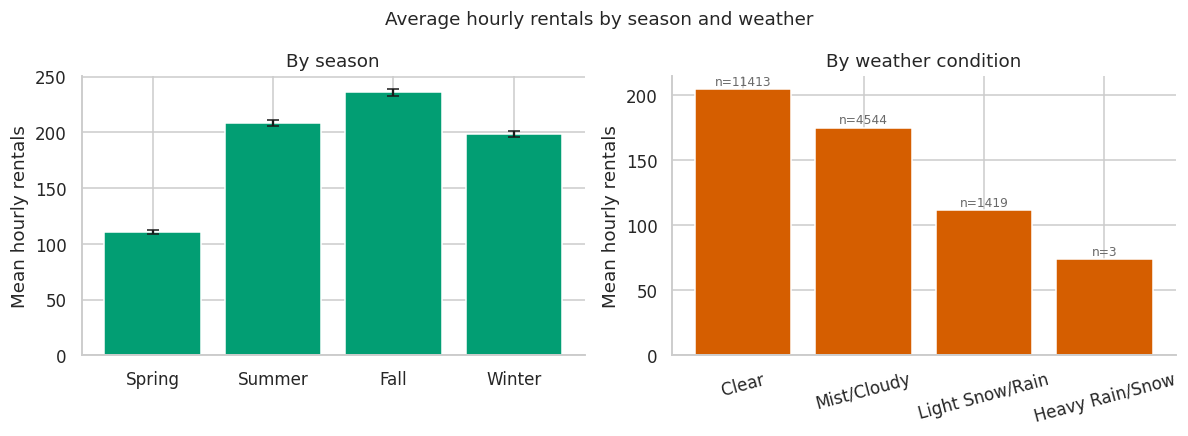

In [56]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
order_s = ['Spring','Summer','Fall','Winter']
means_s = hour.groupby('season_name')['cnt'].mean().reindex(order_s)
sems_s  = hour.groupby('season_name')['cnt'].sem().reindex(order_s)
axes[0].bar(order_s, means_s.values, yerr=sems_s.values, color=sns.color_palette("colorblind")[2], capsize=4)
axes[0].set_ylabel('Mean hourly rentals'); axes[0].set_title('By season')

order_w = ['Clear','Mist/Cloudy','Light Snow/Rain','Heavy Rain/Snow']
means_w = hour.groupby('weather_name')['cnt'].mean().reindex(order_w)
counts_w = hour.groupby('weather_name')['cnt'].count().reindex(order_w)
axes[1].bar(order_w, means_w.values, color=sns.color_palette("colorblind")[3])
for i, (m, c) in enumerate(zip(means_w.values, counts_w.values)):
    axes[1].text(i, m + 3, f'n={c}', ha='center', fontsize=8, color='dimgray')
axes[1].set_ylabel('Mean hourly rentals'); axes[1].set_title('By weather condition')
axes[1].tick_params(axis='x', rotation=15)
fig.suptitle('Average hourly rentals by season and weather')
fig.tight_layout()

**Observation:** demand is highest in **Fall** and lowest in **Spring** (counter to a naive "warmer = more riders" prior — Spring in this D.C. dataset is early-year and includes the coldest months numerically assigned to season 1). Demand falls monotonically with weather severity; the most severe category (`weathersit=4`) has only **3 recorded hours** in two years and should not be trusted for precise inference (flagged again in Task 2).

### 1.8 Monthly pattern and yearly growth

I compared monthly rentals in 2011 and 2012 to see both the seasonal pattern and whether overall use of the system increased over time.


Annual totals:
yr
2011    1243103
2012    2049576
Name: cnt, dtype: int64

YoY growth: 64.9%


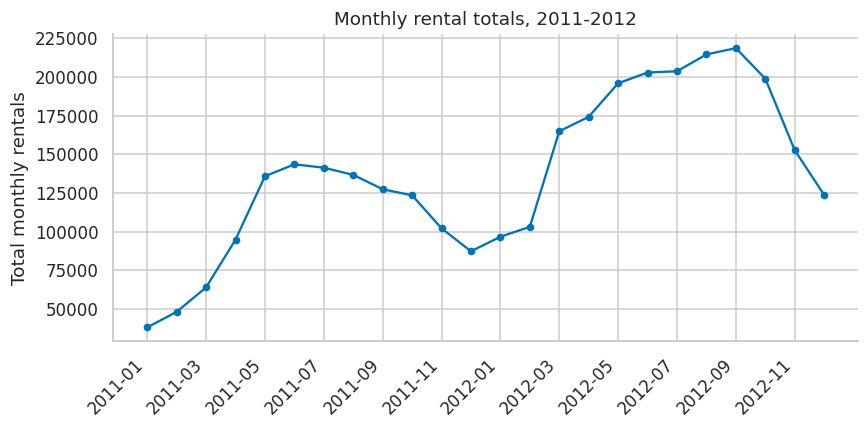

In [57]:
fig, ax = plt.subplots(figsize=(8, 4))
monthly = hour.groupby(['yr', 'mnth'])['cnt'].sum().reset_index()
monthly['label'] = monthly['yr'].map({0:'2011', 1:'2012'}) + '-' + monthly['mnth'].astype(str).str.zfill(2)
ax.plot(range(len(monthly)), monthly['cnt'], marker='o', ms=4, color=sns.color_palette("colorblind")[0])
ax.set_xticks(range(0, len(monthly), 2))
ax.set_xticklabels(monthly['label'][::2], rotation=45, ha='right')
ax.set_ylabel('Total monthly rentals'); ax.set_title('Monthly rental totals, 2011-2012')
fig.tight_layout()

print("Annual totals:"); print(hour.groupby('yr')['cnt'].sum().rename(index={0:'2011',1:'2012'}))
print(f"\nYoY growth: {hour.groupby('yr')['cnt'].sum().iloc[1] / hour.groupby('yr')['cnt'].sum().iloc[0] - 1:.1%}")

**Observation:** total rentals grew **~65% year-over-year** (2011 → 2012), on top of the seasonal cycle — a program-adoption trend that the regression (Task 2, via `yr`) and forecasting model (Task 3) both need to capture explicitly rather than assume stationarity.

### 1.9 Unusual demand period

Very low or high rental counts are not always data errors. I checked the lowest-demand period to see whether it could be connected to a real event rather than simply removing it as an outlier.


dteday
2012-10-29     22
2011-01-27    431
2012-12-26    441
2011-01-26    506
2011-03-06    605
Name: cnt, dtype: int64


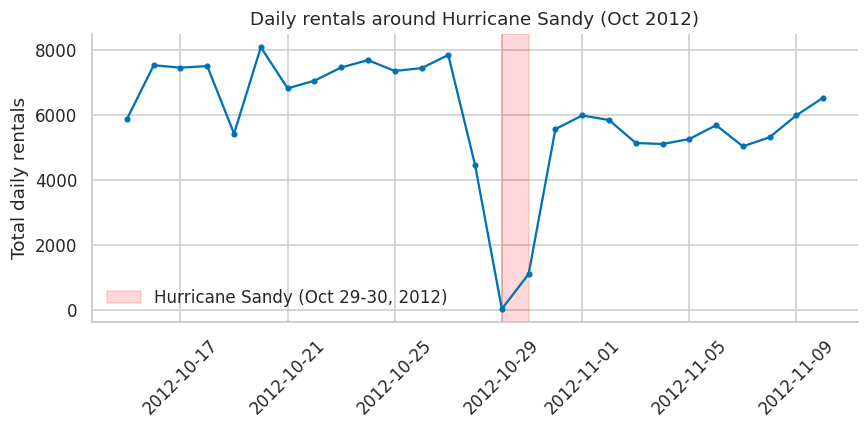

In [58]:
fig, ax = plt.subplots(figsize=(8, 4))
daily = hour.groupby('dteday')['cnt'].sum()
window = daily.loc['2012-10-15':'2012-11-10']
ax.plot(window.index, window.values, marker='o', ms=3, color=sns.color_palette("colorblind")[0])
ax.axvspan(pd.Timestamp('2012-10-29'), pd.Timestamp('2012-10-30'), color='red', alpha=0.15,
           label='Hurricane Sandy (Oct 29-30, 2012)')
ax.set_ylabel('Total daily rentals'); ax.set_title('Daily rentals around Hurricane Sandy (Oct 2012)')
ax.legend(frameon=False); ax.tick_params(axis='x', rotation=45)
fig.tight_layout()

print(daily.sort_values().head(5))

**Observation:**  
October 29, 2012 has the lowest daily rental total in the dataset (`cnt = 22`), and the
plot shows strongly depressed demand around October 29–30. This period coincides with
Hurricane Sandy's impact on the Mid-Atlantic region, providing a plausible external
explanation for the extreme reduction in bikeshare activity.

This is a descriptive association rather than a causal estimate. The key modeling
lesson is that extreme observations can represent genuine demand shocks and therefore
should not be removed automatically using a generic outlier rule.


### 1.10 Correlation check
  
The correlation matrix helps identify variables that contain very similar information. This is especially useful before regression because strongly related predictors can create multicollinearity problems.


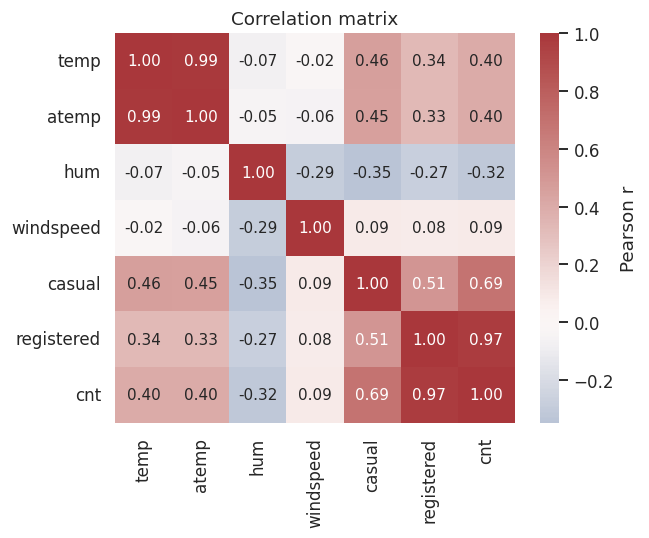

In [59]:
corr_cols = ['temp','atemp','hum','windspeed','casual','registered','cnt']
corr = hour[corr_cols].corr()
fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='vlag', center=0, ax=ax, cbar_kws={'label': 'Pearson r'})
ax.set_title('Correlation matrix')
fig.tight_layout()

**Observation**  
`temp` and `atemp` are almost perfectly correlated (`r ≈ 0.988`), indicating that they
contain nearly duplicate thermal information. Rather than dropping one variable based
on correlation alone, this potential multicollinearity is formally evaluated using
variance inflation factors (VIF) in Task 2.

`registered` is more strongly correlated with total `cnt` than `casual`, largely
because registered riders account for a larger share of total volume. Since both are
components of `cnt`, these correlations are descriptive only and are not used to
justify including them as predictors of total demand.


### 1.11 What I learned from the exploratory analysis

The data shows clear patterns that are useful for the next steps. Demand changes strongly by hour, working-day status, season, and weather. Registered riders mainly create the morning and evening commuting peaks, while casual riders are more active during weekends and daytime. Rental counts are also highly variable and overdispersed, and `temp` and `atemp` contain almost the same information. These findings guide the regression and forecasting models used next.


## Task 2 — Statistical & Regression Analysis

**Dependent variable:** `cnt` (total hourly rentals). **Candidate predictors:** `season`, `weathersit`, `temp`/`atemp`, `hum`, `windspeed`, `hr`, `weekday`, `workingday`, `holiday`, `yr`.

### 2.1 Multicollinearity (VIF)

In [60]:
cont = sm.add_constant(hour[['temp','atemp','hum','windspeed']])
vif = pd.DataFrame({'variable': cont.columns,
                     'VIF': [variance_inflation_factor(cont.values, i) for i in range(cont.shape[1])]})
print("With both temp & atemp:"); display(vif)

cont2 = sm.add_constant(hour[['temp','hum','windspeed']])
vif2 = pd.DataFrame({'variable': cont2.columns,
                      'VIF': [variance_inflation_factor(cont2.values, i) for i in range(cont2.shape[1])]})
print("After dropping atemp:"); display(vif2)

With both temp & atemp:


,variable,VIF
0,const,1.000000
1,temp,43.550327
2,atemp,43.651270
3,hum,1.100575
4,windspeed,1.156293


After dropping atemp:


,variable,VIF
0,const,1.000000
1,temp,1.006988
2,hum,1.098937
3,windspeed,1.094156


**Finding:** VIF for `temp`/`atemp` is **~43.6** with both included (severe multicollinearity; a common rule of thumb flags VIF > 10) and drops to ~1.0 once `atemp` is removed. **`atemp` is dropped**, keeping `temp` as the primary thermal predictor because the two carry near-identical information (r = 0.988).

`workingday`, `weekday`, and `holiday` also encode overlapping calendar information. Rather than claim exact linear collinearity, the primary specification uses the more parsimonious `workingday + holiday` representation; a `weekday + holiday` alternative is fit below as a robustness check.


In [61]:
check = hour.groupby(['weekday','holiday'])['workingday'].nunique()
print("Every (weekday, holiday) combination maps to exactly one workingday value:",
      (check == 1).all(), f"  [{check.nunique()} distinct outcome per combo]")

Every (weekday, holiday) combination maps to exactly one workingday value: True   [1 distinct outcome per combo]


### 2.2 Choosing the regression model

`cnt` is a count variable and its variance is much larger than its mean. I therefore compared OLS, Poisson, and Negative Binomial models to find a model that better matches the data.


In [62]:
formula_A = "cnt ~ temp + hum + windspeed + C(season) + C(weathersit) + C(hr) + workingday + holiday + yr"
formula_B = "cnt ~ temp + hum + windspeed + C(season) + C(weathersit) + C(hr) + C(weekday) + holiday + yr"

ols = smf.ols(formula_A, data=hour).fit()
print(f"OLS:      R2={ols.rsquared:.3f}  AIC={ols.aic:.0f}  "
      f"share of impossible negative fitted values={(ols.fittedvalues < 0).mean():.1%}")

poisson = smf.glm(formula_A, data=hour, family=sm.families.Poisson()).fit()
print(f"Poisson:  AIC={poisson.aic:.0f}  deviance/df_resid (overdispersion)={poisson.deviance/poisson.df_resid:.1f}  "
      f"(should be ~1 if Poisson is adequate)")

OLS:      R2=0.681  AIC=210290  share of impossible negative fitted values=10.3%
Poisson:  AIC=700185  deviance/df_resid (overdispersion)=34.0  (should be ~1 if Poisson is adequate)


**Finding:** OLS assigns physically **impossible negative predicted counts** to ~10% of observations, and its constant-variance assumption is clearly wrong given the overdispersion. A Poisson GLM enforces non-negativity via the log link but its dispersion statistic (deviance/df ≈ **34**) is far above the value of 1 implied by the Poisson assumption (mean = variance) — Poisson standard errors would be badly understated. A **Negative Binomial (NB2) GLM**, which adds a free dispersion parameter, is the appropriate choice.

### 2.3 Negative Binomial GLM — dispersion selection and final fit

In [63]:
alphas = [0.05,0.1,0.15,0.2,0.25,0.3,0.4,0.5,0.7,1.0]
grid = []
for a in alphas:
    m = smf.glm(formula_A, data=hour, family=sm.families.NegativeBinomial(alpha=a)).fit()
    grid.append((a, m.aic, m.pearson_chi2/m.df_resid))
grid = pd.DataFrame(grid, columns=['alpha','AIC','pearson_chi2_over_df'])
display(grid)
best_alpha = grid.loc[grid['AIC'].idxmin(), 'alpha']
print("Best alpha (min AIC):", best_alpha)

,alpha,AIC,pearson_chi2_over_df
0,0.05,219682.736358,3.828460
1,0.10,197965.785998,2.190313
2,0.15,191568.331515,1.548985
3,0.20,189256.560535,1.202164
4,0.25,188533.175455,0.983727
5,0.30,188546.936684,0.833133
6,0.40,189532.008346,0.638562
7,0.50,191004.019959,0.518045
8,0.70,194219.156044,0.376401
9,1.00,198744.810731,0.267117


Best alpha (min AIC): 0.25


In [64]:
nb_A = smf.glm(formula_A, data=hour, family=sm.families.NegativeBinomial(alpha=best_alpha)).fit()
nb_B = smf.glm(formula_B, data=hour, family=sm.families.NegativeBinomial(alpha=best_alpha)).fit()
print(f"Model A (workingday+holiday): AIC={nb_A.aic:.0f}")
print(f"Model B (weekday+holiday):    AIC={nb_B.aic:.0f}  (marginally better fit; more granular, less parsimonious)")
print(f"\nFinal model (A) Pearson chi2/df = {nb_A.pearson_chi2/nb_A.df_resid:.2f}  (near 1 -> dispersion well-modeled)")
nb_A.summary()

Model A (workingday+holiday): AIC=188533
Model B (weekday+holiday):    AIC=188467  (marginally better fit; more granular, less parsimonious)

Final model (A) Pearson chi2/df = 0.98  (near 1 -> dispersion well-modeled)


<class 'statsmodels.iolib.summary.Summary'>
"""
                 Generalized Linear Model Regression Results                  
==============================================================================
Dep. Variable:                    cnt   No. Observations:                17379
Model:                            GLM   Df Residuals:                    17343
Model Family:        NegativeBinomial   Df Model:                           35
Link Function:                    Log   Scale:                          1.0000
Method:                          IRLS   Log-Likelihood:                -94231.
Date:                Fri, 25 Sep 2026   Deviance:                       20029.
Time:                        16:21:37   Pearson chi2:                 1.71e+04
No. Iterations:                    15   Pseudo R-squ. (CS):             0.9827
Covariance Type:            nonrobust                                         
======================================================================================
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept              3.0108      0.031     98.029      0.000       2.951       3.071
C(season)[T.2]         0.3233      0.014     22.491      0.000       0.295       0.351
C(season)[T.3]         0.2733      0.018     14.777      0.000       0.237       0.310
C(season)[T.4]         0.4896      0.012     39.440      0.000       0.465       0.514
C(weathersit)[T.2]    -0.0433      0.010     -4.431      0.000      -0.062      -0.024
C(weathersit)[T.3]    -0.5040      0.017    -30.197      0.000      -0.537      -0.471
C(weathersit)[T.4]    -0.3075      0.304     -1.010      0.312      -0.904       0.289
C(hr)[T.1]            -0.4691      0.028    -16.855      0.000      -0.524      -0.415
C(hr)[T.2]            -0.8335      0.028    -29.422      0.000      -0.889      -0.778
C(hr)[T.3]            -1.4859      0.030    -50.066      0.000      -1.544      -1.428
C(hr)[T.4]            -2.0558      0.031    -65.377      0.000      -2.117      -1.994
C(hr)[T.5]            -0.8744      0.028    -30.740      0.000      -0.930      -0.819
C(hr)[T.6]             0.4926      0.027     18.033      0.000       0.439       0.546
C(hr)[T.7]             1.5123      0.027     55.959      0.000       1.459       1.565
C(hr)[T.8]             2.0428      0.027     75.818      0.000       1.990       2.096
C(hr)[T.9]             1.5002      0.027     55.502      0.000       1.447       1.553
C(hr)[T.10]            1.1494      0.027     42.297      0.000       1.096       1.203
C(hr)[T.11]            1.2791      0.027     46.834      0.000       1.226       1.333
C(hr)[T.12]            1.4588      0.027     53.094      0.000       1.405       1.513
C(hr)[T.13]            1.4371      0.028     52.024      0.000       1.383       1.491
C(hr)[T.14]            1.3697      0.028     49.347      0.000       1.315       1.424
C(hr)[T.15]            1.4121      0.028     50.814      0.000       1.358       1.467
C(hr)[T.16]            1.6360      0.028     59.029      0.000       1.582       1.690
C(hr)[T.17]            2.0734      0.028     75.258      0.000       2.019       2.127
C(hr)[T.18]            2.0100      0.027     73.327      0.000       1.956       2.064
C(hr)[T.19]            1.7053      0.027     62.645      0.000       1.652       1.759
C(hr)[T.20]            1.4050      0.027     51.772      0.000       1.352       1.458
C(hr)[T.21]            1.1521      0.027     42.534      0.000       1.099       1.205
C(hr)[T.22]            0.8968      0.027     33.087      0.000       0.844       0.950
C(hr)[T.23]            0.5125      0.027     18.836      0.000       0.459       0.566
temp                   1.4734      0.036     40.986      0.000       1.403       1.544
hum                   -0.1945      0.027     -7.079      0.000      -0.248      -0.141
windspeed             -0.2277      0.0

**Handling nonlinearity:** Hour, season, and weather are treated as categories instead of simple continuous numbers. This is useful because their effects are not expected to change in a straight-line pattern. For example, hourly demand has separate morning and evening peaks.

### 2.4 Understanding the model results — incidence rate ratios (IRR)


In [65]:
key_vars = ['temp','hum','windspeed','workingday','holiday','yr']
irr = np.exp(nb_A.params[key_vars])
ci  = np.exp(nb_A.conf_int().loc[key_vars])
tab = pd.DataFrame({'IRR': irr, 'CI_low': ci[0], 'CI_high': ci[1], 'p_value': nb_A.pvalues[key_vars]})
tab.round(4)

,IRR,CI_low,CI_high,p_value
temp,4.3638,4.0670,4.6824,0.0
hum,0.8232,0.7801,0.8688,0.0
windspeed,0.7964,0.7442,0.8522,0.0
workingday,0.8172,0.8033,0.8313,0.0
holiday,0.7425,0.7077,0.7790,0.0
yr,1.6041,1.5793,1.6293,0.0


**Reading the IRRs (holding other variables fixed):** moving `temp` from its minimum (0) to maximum (1, i.e. ~41°C normalized scale) is associated with a **4.37×** increase in expected rentals — the single strongest effect in the model. A 1-unit increase in normalized humidity is associated with an 18% decrease (IRR 0.82); working days see 19% *fewer* total rentals than non-working days (IRR 0.81) once hour-of-day is already controlled for (i.e., this is the residual day-type effect after the hourly commute pattern is accounted for separately); year-over-year the base rate is **1.60×** higher in 2012 than 2011, consistent with the ~65% raw growth seen in Task 1.

### 2.5 Casual vs. registered riders behave differently — separate NB models

In [66]:
for target, a in [('casual', 0.5), ('registered', 0.5)]:
    f = f"{target} ~ temp + hum + windspeed + C(season) + C(weathersit) + C(hr) + workingday + holiday + yr"
    m = smf.glm(f, data=hour, family=sm.families.NegativeBinomial(alpha=a)).fit()
    irr_t = np.exp(m.params[key_vars])
    print(f"--- {target} (AIC={m.aic:.0f}) ---")
    display(pd.DataFrame({'IRR': irr_t.round(3), 'p_value': m.pvalues[key_vars].round(4)}))

--- casual (AIC=127611) ---


,IRR,p_value
temp,21.685,0.0
hum,0.703,0.0
windspeed,0.661,0.0
workingday,0.444,0.0
holiday,0.739,0.0
yr,1.369,0.0


--- registered (AIC=184540) ---


,IRR,p_value
temp,3.271,0.0000
hum,0.854,0.0000
windspeed,0.838,0.0002
workingday,0.929,0.0000
holiday,0.737,0.0000
yr,1.653,0.0000


**Finding:** `workingday` has **opposite-magnitude** effects — casual rentals fall to **44%** of their weekend/holiday level on working days (IRR 0.44), while registered rentals fall only to 93% (IRR 0.93, a much smaller drop). `temp` sensitivity is also far larger for casual riders (IRR ≈ 21.7 vs. ≈ 3.3 for registered) across the full normalized temperature scale. This statistically confirms the pattern seen in Task 1: **casual riders are more weather- and leisure-day-sensitive, whereas registered demand is comparatively less sensitive to those factors.**

**Summary of statistical issues addressed:** (1) count-data distribution → Negative Binomial GLM in place of OLS/Poisson; (2) multicollinearity → dropped `atemp` (VIF 43.6 → ~1.0); (3) overlapping day-type information → used a parsimonious `workingday + holiday` primary specification and checked a weekday alternative; (4) non-linearity → categorical (not linear/ordinal) encoding of `hr`, `season`, and `weathersit`; (5) rare category → `weathersit=4` has only 3 observations, so conclusions about the most severe weather category are treated cautiously.


## Task 3 — Demand Forecasting & Predictive Modeling

### 3.1 Train/test split

For every month, days **1–20** are used for training and days **21–end** are used for testing, as required in the assessment.

### 3.2 Avoiding data leakage

For the main forecasting model, I used calendar and weather information without rental-count lag features. This prevents the model from using actual bike-demand values from inside the test period.

To keep the evaluation fair:

1. `casual` and `registered` are not used because together they equal `cnt`.
2. The main model does not use lag or rolling features created from actual `cnt` values inside the test window.
3. Calendar, weather, and cyclical time features are used as predictors.

I also tested a lag-based LightGBM as an additional comparison. It performs better, but it assumes that previous observed rental counts become available during the test period, so it is not used as the main result.

**Weather assumption:** The dataset does not include a separate weather-forecast file. For this analysis, weather variables are treated as information available at prediction time.


In [67]:
df = hour.copy()
df['day_of_month'] = df['dteday'].dt.day

full_idx = pd.date_range(df['datetime'].min(), df['datetime'].max(), freq='h')
cnt_series = df.set_index('datetime')['cnt'].reindex(full_idx)

lag_df = pd.DataFrame({
    'lag_1':    cnt_series.shift(1),
    'lag_24':   cnt_series.shift(24),
    'lag_168':  cnt_series.shift(168),
    'roll_24':  cnt_series.shift(1).rolling(24,  min_periods=12).mean(),
    'roll_168': cnt_series.shift(1).rolling(168, min_periods=48).mean(),
})
lag_df.index.name = 'datetime'
df = df.merge(lag_df, left_on='datetime', right_index=True, how='left')

train_mask = df['day_of_month'] <= 20
test_mask  = df['day_of_month'] > 20
print(f"Train rows: {train_mask.sum()}  ({train_mask.mean():.1%})   Test rows: {test_mask.sum()}  ({test_mask.mean():.1%})")
print("\nNaN lag values before fallback:\n", df.loc[:, ['lag_1','lag_24','lag_168','roll_24','roll_168']].isna().sum())

train_clim = df.loc[train_mask].groupby(['hr','season'])['cnt'].mean().rename('clim')
df = df.merge(train_clim, on=['hr','season'], how='left')
for c in ['lag_1','lag_24','lag_168','roll_24','roll_168']:
    df[c] = df[c].fillna(df['clim'])
print("\nRemaining NaN after train-only climatology fallback:",
      df[['lag_1','lag_24','lag_168','roll_24','roll_168']].isna().sum().sum())

df['hr_sin'] = np.sin(2*np.pi*df['hr']/24);       df['hr_cos'] = np.cos(2*np.pi*df['hr']/24)
df['mnth_sin'] = np.sin(2*np.pi*df['mnth']/12);   df['mnth_cos'] = np.cos(2*np.pi*df['mnth']/12)
df['wday_sin'] = np.sin(2*np.pi*df['weekday']/7); df['wday_cos'] = np.cos(2*np.pi*df['weekday']/7)

Train rows: 11460  (65.9%)   Test rows: 5919  (34.1%)

NaN lag values before fallback:
 lag_1        76
lag_24      160
lag_168     304
roll_24      48
roll_168     48
dtype: int64

Remaining NaN after train-only climatology fallback: 0


### 3.3 Evaluation metrics

- **RMSLE:** useful for comparing relative prediction error when rental counts are skewed.
- **MAE / RMSE:** show prediction error in bikes per hour.
- **R²:** shows how much of the variation in demand is explained by the model.

### 3.4 Models compared

- **Negative Binomial GLM:** used as a statistical baseline with weather and calendar features.
- **LightGBM without target lags:** the main forecasting model. It uses calendar and weather information without actual rental counts from the test period.
- **LightGBM with lag features:** included as an additional rolling one-step-ahead comparison.
- **Seasonal naive:** uses the same hour from the previous week as a simple historical reference.


In [68]:
cat_cols = ['season','weathersit','weekday','mnth','hr']
for c in cat_cols:
    df[c] = df[c].astype('category')

feature_cols = cat_cols + ['yr','holiday','workingday','temp','hum','windspeed',
                            'hr_sin','hr_cos','mnth_sin','mnth_cos','wday_sin','wday_cos',
                            'lag_1','lag_24','lag_168','roll_24','roll_168']

train = df[df['day_of_month'] <= 20].copy()
test  = df[df['day_of_month'] > 20].copy()

def rmsle(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return np.sqrt(np.mean((np.log1p(y_pred) - np.log1p(y_true))**2))

def metrics(y_true, y_pred):
    y_pred = np.clip(y_pred, 0, None)
    return dict(MAE=mean_absolute_error(y_true, y_pred),
                RMSE=np.sqrt(mean_squared_error(y_true, y_pred)),
                RMSLE=rmsle(y_true, y_pred),
                R2=r2_score(y_true, y_pred))

results = {}
results['Seasonal naive (rolling reference)'] = metrics(test['cnt'].values, test['lag_168'].values)

formula_A = "cnt ~ temp + hum + windspeed + C(season) + C(weathersit) + C(hr) + workingday + holiday + yr"
nb_train = smf.glm(formula_A, data=train, family=sm.families.NegativeBinomial(alpha=0.25)).fit()
results['NB GLM (weather+calendar only)'] = metrics(test['cnt'].values, nb_train.predict(test).values)

X_train, y_train_log = train[feature_cols], np.log1p(train['cnt'])
X_test = test[feature_cols]

lgb_full = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                              min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                              reg_lambda=1.0, random_state=42, verbosity=-1)
lgb_full.fit(X_train, y_train_log, categorical_feature=cat_cols)
pred_full = np.expm1(lgb_full.predict(X_test))
results['LightGBM (supplementary rolling-lag)'] = metrics(test['cnt'].values, pred_full)

feat_no_lag = [c for c in feature_cols if c not in ['lag_1','lag_24','lag_168','roll_24','roll_168']]
lgb_nolag = lgb.LGBMRegressor(n_estimators=600, learning_rate=0.03, num_leaves=31,
                               min_child_samples=20, subsample=0.8, colsample_bytree=0.8,
                               reg_lambda=1.0, random_state=42, verbosity=-1)
lgb_nolag.fit(train[feat_no_lag], y_train_log, categorical_feature=cat_cols)
pred_nolag = np.expm1(lgb_nolag.predict(test[feat_no_lag]))
results['LightGBM (PRIMARY: strict no-target-lag)'] = metrics(test['cnt'].values, pred_nolag)

results_df = pd.DataFrame(results).T.round(3)
results_df

,MAE,RMSE,RMSLE,R2
Seasonal naive (rolling reference),58.160,101.672,0.651,0.685
NB GLM (weather+calendar only),66.261,106.132,0.664,0.657
LightGBM (supplementary rolling-lag),22.351,36.559,0.292,0.959
LightGBM (PRIMARY: strict no-target-lag),33.256,56.274,0.415,0.903


**Finding:** under the strict assessment interpretation, the **primary no-target-lag LightGBM** achieves **MAE = 33.256, RMSE = 56.274, RMSLE = 0.415, and R² = 0.903** on the held-out day-21-to-end windows. This shows that calendar and weather structure alone explain most of the variation without using observed target values from inside an evaluation window.

The supplementary rolling-lag model reaches R² ≈ 0.96 and RMSLE ≈ 0.29, but it assumes previous observed rental counts become available during the evaluation window. I therefore report it only as a rolling one-step-ahead sensitivity analysis, not as the primary assessment result.


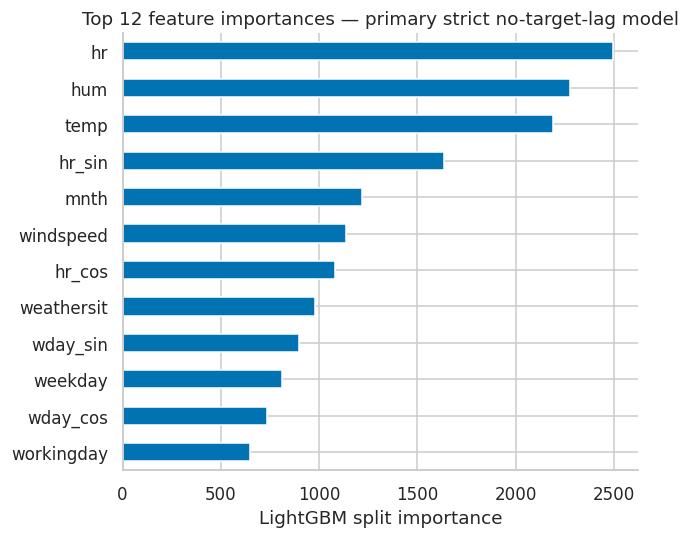

In [69]:
imp = pd.Series(lgb_nolag.feature_importances_, index=feat_no_lag).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(6,5))
imp.head(12).iloc[::-1].plot.barh(ax=ax, color=sns.color_palette("colorblind")[0])
ax.set_xlabel('LightGBM split importance')
ax.set_title('Top 12 feature importances — primary strict no-target-lag model')
fig.tight_layout()


**What this shows:** The feature-importance plot shows which calendar and weather variables are most useful to the main LightGBM model.

### 3.5 Performance across the 24 monthly test windows


In [70]:
test = test.copy()
test['pred'] = np.clip(pred_nolag, 0, None)
test['ym'] = test['yr'].map({0:'2011', 1:'2012'}) + '-' + test['mnth'].astype(int).astype(str).str.zfill(2)

monthly_perf = test.groupby('ym', observed=True).apply(
    lambda g: pd.Series(metrics(g['cnt'].values, g['pred'].values))
).reset_index()

monthly_perf.round(3)


/tmp/ipykernel_2291/1733926500.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  monthly_perf = test.groupby('ym', observed=True).apply(


,ym,MAE,RMSE,RMSLE,R2
0,2011-01,11.430,17.800,0.347,0.859
1,2011-02,17.333,26.408,0.414,0.824
2,2011-03,17.114,27.463,0.375,0.870
3,2011-04,43.644,63.381,0.420,0.811
4,2011-05,25.419,37.914,0.252,0.935
5,2011-06,21.517,31.075,0.193,0.963
6,2011-07,24.460,35.736,0.228,0.919
7,2011-08,30.022,56.943,0.409,0.876
8,2011-09,43.065,64.209,0.425,0.821
9,2011-10,21.573,32.116,0.378,0.944


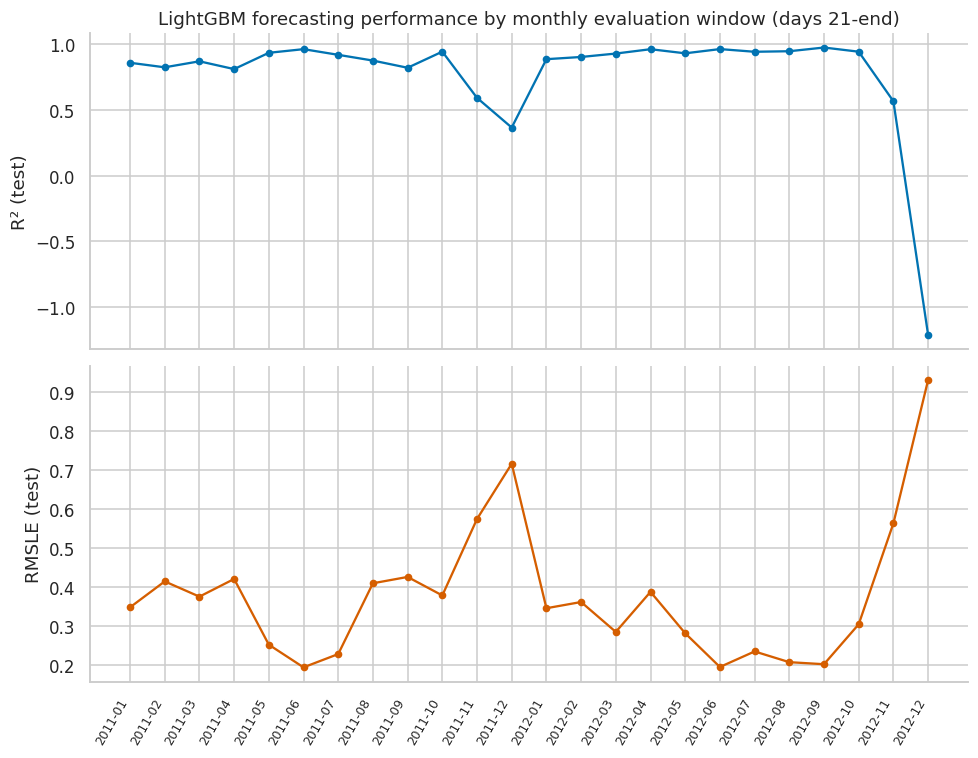

In [71]:
fig, axes = plt.subplots(2, 1, figsize=(9, 7), sharex=True)
x = range(len(monthly_perf))
axes[0].plot(x, monthly_perf['R2'], marker='o', ms=4, color=sns.color_palette('colorblind')[0])
axes[0].set_ylabel('R² (test)'); axes[0].set_title('LightGBM forecasting performance by monthly evaluation window (days 21-end)')
axes[1].plot(x, monthly_perf['RMSLE'], marker='o', ms=4, color=sns.color_palette('colorblind')[3])
axes[1].set_ylabel('RMSLE (test)')
axes[1].set_xticks(x); axes[1].set_xticklabels(monthly_perf['ym'], rotation=60, ha='right', fontsize=8)
fig.tight_layout()

**What this shows:** Model performance changes from month to month. Looking at all 24 test windows gives a better picture of how consistently the model predicts demand instead of judging it from only one month.


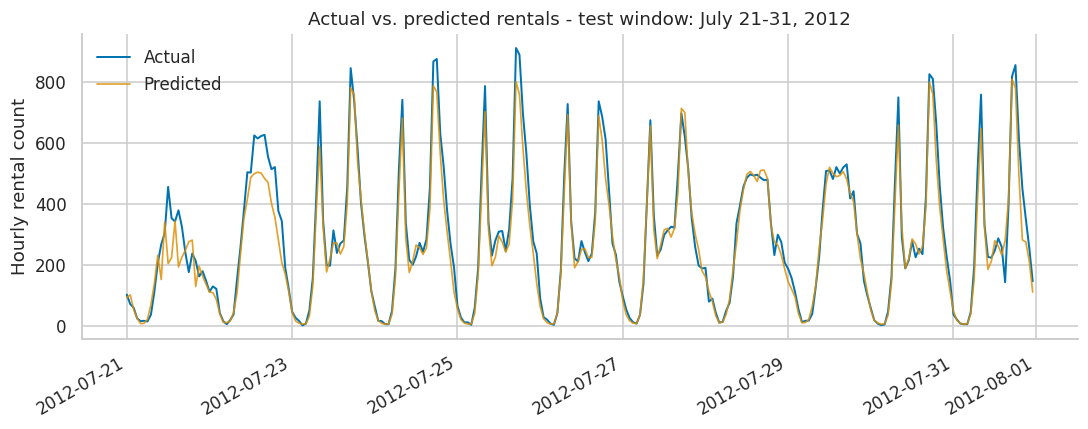

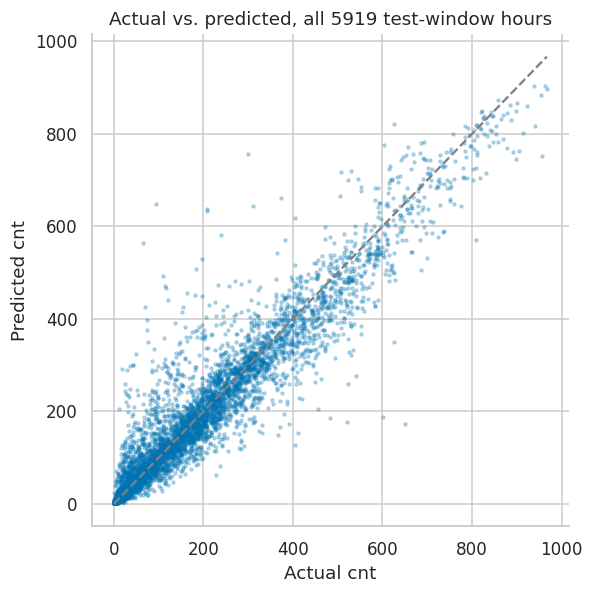

In [72]:
example = test[test['ym'] == '2012-07'].sort_values('datetime')
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(example['datetime'], example['cnt'], lw=1.3, label='Actual', color=sns.color_palette('colorblind')[0])
ax.plot(example['datetime'], example['pred'], lw=1.1, label='Predicted', color=sns.color_palette('colorblind')[1], alpha=0.85)
ax.set_ylabel('Hourly rental count')
ax.set_title('Actual vs. predicted rentals - test window: July 21-31, 2012')
ax.legend(frameon=False)
fig.autofmt_xdate(); fig.tight_layout()

fig2, ax2 = plt.subplots(figsize=(5.5, 5.5))
ax2.scatter(test['cnt'], test['pred'], s=4, alpha=0.25, color=sns.color_palette('colorblind')[0])
lims = [0, max(test['cnt'].max(), test['pred'].max())]
ax2.plot(lims, lims, color='gray', lw=1.5, ls='--')
ax2.set_xlabel('Actual cnt'); ax2.set_ylabel('Predicted cnt')
ax2.set_title(f'Actual vs. predicted, all {len(test)} test-window hours')
fig2.tight_layout()

**Observation:** The July 2012 example compares the predicted rentals with the actual rentals. The model follows the main daily pattern well, but some sudden hour-to-hour changes are harder to predict without using recent rental history.

